# London Airbnb Price Regression

Predicting nightly listing price from Inside Airbnb's London snapshot. This mirrors the
kind of automated valuation problem a short-term rental platform, property manager, or
pricing tool would solve in production: given a listing's attributes, estimate what it
should charge.

Data: Inside Airbnb London, `listings.csv.gz` (CC BY 4.0, https://insideairbnb.com/london/).
Unlike the Ames Kaggle set, this is raw scraped data, not competition-cleaned. Expect
string-typed prices, stringified amenity lists, and other real-world mess that Ames didn't
have.

Requires `listings.csv` or `listings.csv.gz` in `../data/` relative to this notebook.

### Loading Data

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [2]:
# Update this path to wherever you saved the download.
# pandas reads .csv.gz directly - no need to unzip first.
DATA_PATH = "../data/listings.csv.gz"

df = pd.read_csv(DATA_PATH, low_memory=False)
df.shape


(92638, 90)

### First look

`low_memory=False` matters here: this file has 70+ mixed-type columns, and pandas will
throw a `DtypeWarning` without it. Unlike Ames, nothing here has been pre-typed for a
competition, so `df.info()` is the first real signal of what needs cleaning.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            92638 non-null  int64  
 1   listing_url                                   92638 non-null  str    
 2   scrape_id                                     92638 non-null  int64  
 3   last_scraped                                  92638 non-null  str    
 4   source                                        92638 non-null  str    
 5   name                                          92638 non-null  str    
 6   description                                   90549 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   92633 non-null  str    
 9   host_id                                       92638 non-null  int64  
 1

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,92638.0,NaN,NaN,NaN,817486611018259200.0,654698625546075264.0,11551.0,35406562.0,968829639171326208.0,1425415214414694144.0,1710933572119600384.0
listing_url,92638,92638,https://www.airbnb.com/rooms/11551,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_id,92638.0,NaN,NaN,NaN,20260619061251.0,0.0,20260619061251.0,20260619061251.0,20260619061251.0,20260619061251.0,20260619061251.0
last_scraped,92638,9,2026-06-29,23504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,92638,2,city scrape,61587,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
calculated_host_listings_count,92638.0,NaN,NaN,NaN,16.402599,49.874854,1.0,1.0,2.0,9.0,501.0
calculated_host_listings_count_entire_homes,92638.0,NaN,NaN,NaN,13.988547,48.925545,0.0,0.0,1.0,6.0,500.0
calculated_host_listings_count_private_rooms,92638.0,NaN,NaN,NaN,2.248343,9.551793,0.0,0.0,0.0,1.0,142.0
calculated_host_listings_count_shared_rooms,92638.0,NaN,NaN,NaN,0.028843,0.649517,0.0,0.0,0.0,0.0,25.0


### Target and obvious junk columns

Quick pass before real EDA tomorrow: confirm `price` is the target, flag columns that are
clearly scrape metadata / URLs / IDs rather than signal, and note anything with dtype
`object` that should really be numeric or datetime.

In [5]:
df["price"].head(10)


0    $234.50
1    $127.00
2    $137.50
3    $606.67
4     $68.30
5     $49.06
6        NaN
7        NaN
8        NaN
9    $268.33
Name: price, dtype: str

In [6]:
# object-dtype columns are the ones most likely to need cleaning before modelling
df.dtypes.value_counts()


float64    44
str        28
int64      18
Name: count, dtype: int64

In [7]:
object_cols = df.select_dtypes(include="object").columns.tolist()
len(object_cols), object_cols[:20]


/tmp/ipykernel_487/3284793230.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns.tolist()


(28,
 ['listing_url',
  'last_scraped',
  'source',
  'name',
  'description',
  'picture_url',
  'host_url',
  'host_profile_url',
  'host_name',
  'host_location',
  'host_about',
  'host_is_superhost',
  'host_picture_url',
  'host_has_profile_pic',
  'host_identity_verified',
  'neighbourhood_cleansed',
  'property_type',
  'room_type',
  'bathrooms_text',
  'amenities'])

### Observations

92,638 listings x 90 columns, 63.6 MB in memory. 13 columns are entirely null:
`neighborhood_overview`, `host_since`, `host_response_time`, `host_response_rate`,
`host_acceptance_rate`, `host_thumbnail_url`, `host_neighbourhood`,
`host_total_listings_count`, `host_verifications`, `neighbourhood`,
`neighbourhood_group_cleansed`, `calendar_updated`, `license`, `instant_bookable`. Dead
weight, drop on sight.

`host_since` being null isn't a data quality problem: this snapshot already replaced it
with `hosts_time_as_host_years` / `hosts_time_as_host_months` (92,561 non-null), so host
tenure is available as a ready-made numeric feature with no date parsing needed.

`price` (the target) is a string column, `"$234.50"` style, and needs `$`-strip and float
cast. Only 62,240 of 92,638 rows (67.2%) have it, so ~30k listings have no label at
all. `price_quote_total_price` / `price_quote_price_per_night` are already numeric floats
with the exact same non-null count (62,240), worth checking whether these are just a
cleaned re-derivation of `price`, or a genuinely different quantity (a live quote for a
specific stay), before picking which one to model.

`bathrooms` (62.4% present), `bedrooms` (74.1%), and `beds` (64.9%) are all partially
missing, but `bathrooms_text` is 99.9% complete, likely parseable as a fallback for the
numeric `bathrooms` column instead of imputing from scratch.

`id` is bimodal: the 25th percentile is a normal 8-digit id (35,406,562) but the median
jumps to an 18-digit number (968,829,639,171,326,208). Airbnb changed its ID format
partway through the platform's history, so this column mixes two ID generations. Not
useful as a feature, but good to know it's not corrupted data.

28 object columns total. Clear junk to drop immediately (URLs, scrape metadata, free
text): `listing_url`, `last_scraped`, `source`, `name`, `description`, `picture_url`,
`host_url`, `host_profile_url`, `host_name`, `host_about`, `host_picture_url`,
`calendar_last_scraped`, `price_quote_checkin_date`, `price_quote_checkout_date`,
`price_quote_raw`.

Everything was scraped between `2026-06-19` and `2026-06-29`, a single snapshot rather than
a time series, which matters for how `first_review` / `last_review` / `reviews_per_month`
should be read (recency relative to scrape date, not "today").

First-guess predictors for Tuesday's EDA: `room_type`, `property_type`, `accommodates`,
`bedrooms`/`beds`/`bathrooms`, `neighbourhood_cleansed`, `latitude`/`longitude`,
`amenities` (needs parsing out of its stringified-list form), `review_scores_rating`,
`number_of_reviews`, `availability_365`, `hosts_time_as_host_years`, `host_is_superhost`.

## EDA Part 1

### Cleaning price for EDA

Full imputation/encoding is Thursday's job. For now, just enough cleaning on `price` to
plot it: strip `$`, cast to float, leave the ~33% that are missing as NaN rather than
dropping or filling anything yet.

In [8]:
df["price_clean"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["price_clean"].describe()


count     62240.000000
mean        271.469220
std        2190.599006
min           2.230000
25%         100.000000
50%         180.000000
75%         300.032500
max      527524.000000
Name: price_clean, dtype: float64

### Price distribution

Compare raw vs. log1p. Given yesterday's numbers (price is right-skewed almost by
definition for a market like this), expect log to look far closer to normal.

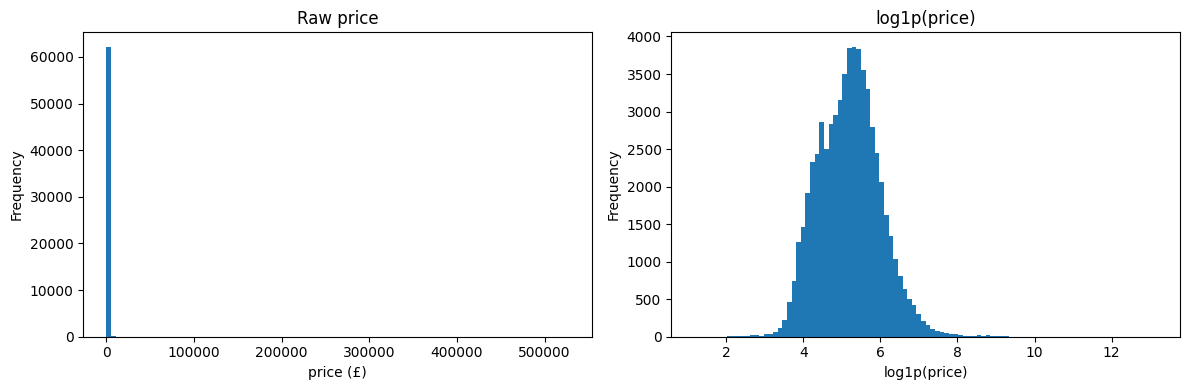

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["price_clean"].dropna().plot(kind="hist", bins=100, ax=axes[0])
axes[0].set_title("Raw price")
axes[0].set_xlabel("price (£)")

np.log1p(df["price_clean"].dropna()).plot(kind="hist", bins=100, ax=axes[1])
axes[1].set_title("log1p(price)")
axes[1].set_xlabel("log1p(price)")

plt.tight_layout()


Raw nightly price is heavily right-skewed, with a long tail of high-end listings pulling the mean well above the median. `log1p` transforms it into a roughly normal distribution centred near the true median of £180 — this is why `log_price` is the regression target used throughout.

### Neighbourhood price heatmap

Two views: a ranked table (which boroughs/neighbourhoods actually command the highest
prices) and a geographic scatter using `latitude`/`longitude` coloured by log price, which
reads as a heatmap without pulling in a mapping library.

In [10]:
neigh_price = (
    df.dropna(subset=["price_clean"])
    .groupby("neighbourhood_cleansed")["price_clean"]
    .median()
    .sort_values(ascending=False)
)
neigh_price


neighbourhood_cleansed
City of London            325.000
Westminster               307.000
Kensington and Chelsea    305.000
Camden                    219.000
Hammersmith and Fulham    199.500
Wandsworth                194.290
Islington                 186.420
Richmond upon Thames      181.170
Tower Hamlets             170.000
Hackney                   167.190
Southwark                 166.000
Newham                    164.250
Lambeth                   164.165
Merton                    160.000
Brent                     150.000
Greenwich                 140.670
Hounslow                  138.000
Barnet                    137.000
Haringey                  136.000
Bromley                   133.070
Kingston upon Thames      125.250
Waltham Forest            122.000
Lewisham                  121.800
Enfield                   115.000
Ealing                    111.000
Havering                  110.000
Harrow                    105.500
Redbridge                 104.000
Croydon                  

Text(0, 0.5, 'latitude')

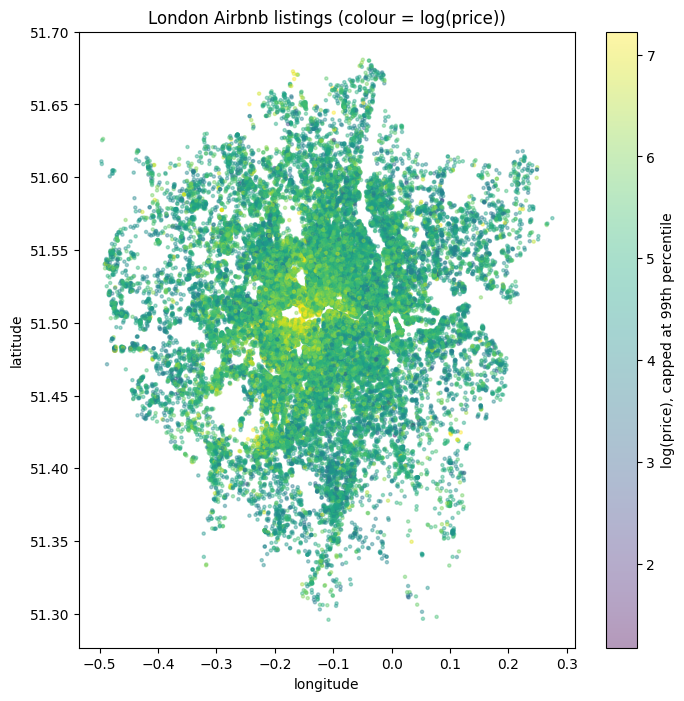

In [11]:
import seaborn as sns

plot_df = df.dropna(subset=["price_clean", "latitude", "longitude"]).copy()
plot_df["log_price"] = np.log1p(plot_df["price_clean"])

plt.figure(figsize=(8, 8))
sc = plt.scatter(
    plot_df["longitude"], plot_df["latitude"],
    c=plot_df["log_price"], cmap="viridis", s=5, alpha=0.4,
    vmax=plot_df["log_price"].quantile(0.99),
)
plt.colorbar(sc, label="log(price), capped at 99th percentile")
plt.title("London Airbnb listings (colour = log(price))")
plt.xlabel("longitude")
plt.ylabel("latitude")


Price rises sharply toward central London. City of London, Westminster, and Kensington & Chelsea top the borough table at roughly 3.8x the cheapest borough (Sutton), confirming location as one of the strongest signals in the dataset.

### Room type breakdown

In [12]:
df["room_type"].value_counts()

room_type
Entire home/apt    61377
Private room       30878
Shared room          203
Hotel room           180
Name: count, dtype: int64

Text(0, 0.5, 'price (£, log scale)')

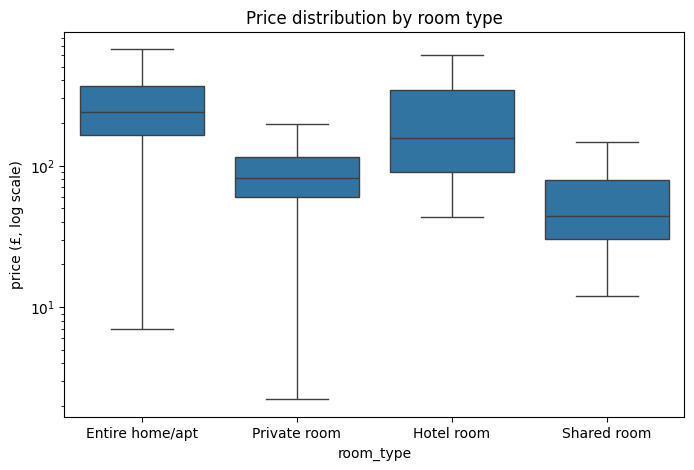

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df.dropna(subset=["price_clean"]),
    x="room_type", y="price_clean", showfliers=False,
)
plt.yscale("log")
plt.title("Price distribution by room type")
plt.ylabel("price (£, log scale)")


Entire home/apartment listings command a clear premium and dominate the dataset (66%). Shared and hotel rooms make up under 0.5% combined — too few listings to trust their price estimates individually.

### Observations

`price_clean` (n=62,240): mean 271.47, median 180, std 2190. Mean and std are close to
meaningless here, since a max of 527,524 against a 75th percentile of just 300 means a
handful of extreme outliers are wrecking the raw scale (max is ~1,750x the median). Some
of these are plausibly real ultra-luxury listings, others look more like data-entry or
scraping errors (a per-stay total leaking into a per-night field, maybe), so it's worth
deciding whether to cap or drop the extreme tail before modelling, not just log-transforming
and moving on.

log1p(price) confirms it's the right target transform: the raw histogram is an unreadable
single spike near zero, and the log version is close to normal and centred around 5.2,
which back-transforms to ~180, right on the actual median.

Neighbourhood table shows a clear, sensible central-London premium: City of London (£325),
Westminster (£307), and Kensington & Chelsea (£305) top the list, falling off steadily
toward outer boroughs, with Sutton (£85.80) cheapest, roughly 3.8x spread top to bottom.
This lines up with real-world intuition, which is a good sign the feature carries real
signal rather than noise.

The geo scatter visually agrees with the table (brighter cluster around the centre/river),
but heavy overplotting at `s=5` with no `alpha` set makes the gradient hard to read
precisely. Worth adding `alpha=0.3-0.5` or switching to a hexbin/2D histogram next time
for a cleaner view.

`room_type` is heavily imbalanced: Entire home/apt (61,377, 66.3%) and Private room
(30,878, 33.3%) dominate; Shared room (203) and Hotel room (180) are each under 0.25% of
the data, barely enough samples to trust their price stats, and Hotel room's box is
visibly wide because of it. Worth flagging as a candidate to collapse into an "Other"
category before modelling rather than one-hot encoding four classes where two are this
thin. Price ordering otherwise matches intuition: Entire home/apt highest, Private/Shared
room lower.

Going into Wednesday: log(price_clean) is the target to carry forward, and both
`neighbourhood_cleansed` and `room_type` look like genuinely predictive categoricals. Still
open: how to handle the ~30k rows with no price at all, and what to do with the extreme
price outliers before they're one-hot encoded and start distorting a linear model.

## EDA Part 2

In [14]:
df["log_price"] = np.log1p(df["price_clean"])

### Reviews vs price

`number_of_reviews` is a volume signal, and `review_scores_rating` is a quality signal.
Worth checking whether either actually moves price, or whether they're more about
occupancy than pricing power.

In [15]:
review_cols = ["number_of_reviews", "reviews_per_month", "review_scores_rating"]
df[review_cols + ["log_price"]].corr()["log_price"]


number_of_reviews      -0.110972
reviews_per_month      -0.064078
review_scores_rating    0.057891
log_price               1.000000
Name: log_price, dtype: float64

Text(0, 0.5, 'price (£, log scale)')

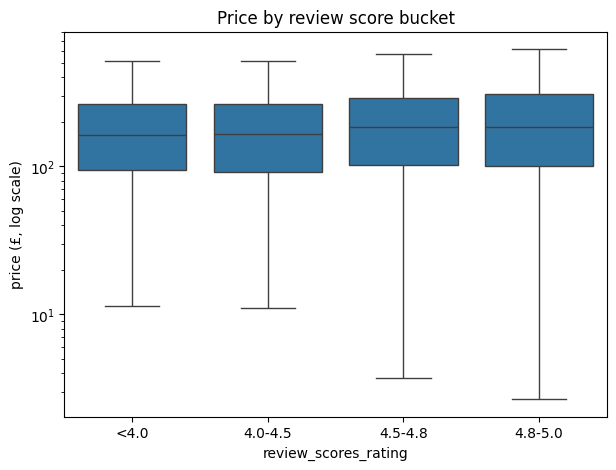

In [16]:
# bucket rating rather than scatter it: ratings cluster tightly near 4.5-5.0,
# a raw scatter would just be a dense vertical smear
rating_bucket = pd.cut(
    df["review_scores_rating"],
    bins=[0, 4.0, 4.5, 4.8, 5.01],
    labels=["<4.0", "4.0-4.5", "4.5-4.8", "4.8-5.0"],
)

plt.figure(figsize=(7, 5))
sns.boxplot(x=rating_bucket, y=df["price_clean"], showfliers=False)
plt.yscale("log")
plt.title("Price by review score bucket")
plt.ylabel("price (£, log scale)")


Review score has only a modest effect on price. Ratings below 4.5 and between 4.5–4.8 look nearly identical, with a small premium once ratings clear 4.8 — review score reads more as a trust signal than a pricing lever.

### Host listings count vs price

Yesterday's null-column list only ruled out `host_total_listings_count`. Check what's
actually populated before assuming a column name.

In [17]:
[c for c in df.columns if "host" in c.lower() and "listing" in c.lower()]


['host_listings_count',
 'host_total_listings_count',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms']

Pick the column from the list above that's actually populated (standard Inside Airbnb
schema calls it `host_listings_count` or `calculated_host_listings_count`, update the
name below if it differs).

In [18]:
HOST_LISTINGS_COL = "host_listings_count"  # update if the check above says otherwise

df[[HOST_LISTINGS_COL, "log_price"]].corr()["log_price"]


host_listings_count    0.129566
log_price              1.000000
Name: log_price, dtype: float64

### Availability patterns

`availability_365` near 0 usually means the calendar is blocked (not actually bookable,
maybe owner-blocked or off-platform), not that the listing is in high demand. Worth
keeping that distinction in mind rather than reading low availability as "sells out fast"

In [19]:
avail_cols = ["availability_30", "availability_60", "availability_90", "availability_365"]
df[avail_cols + ["log_price"]].corr()["log_price"]


availability_30    -0.007825
availability_60     0.001855
availability_90     0.006254
availability_365    0.049334
log_price           1.000000
Name: log_price, dtype: float64

Text(0, 0.5, 'price (£, log scale)')

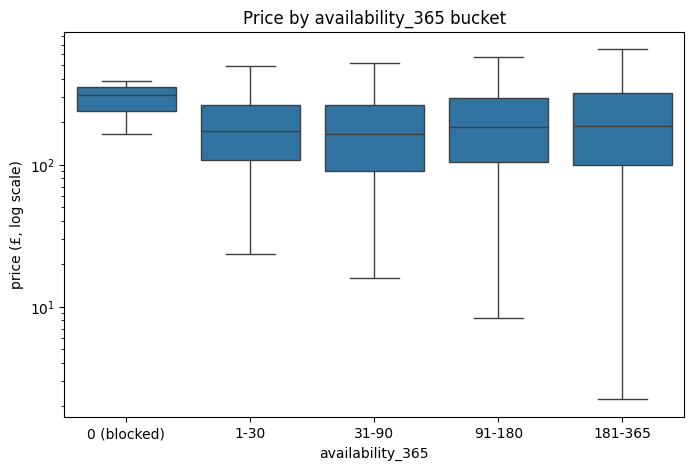

In [20]:
avail_bucket = pd.cut(
    df["availability_365"],
    bins=[-1, 0, 30, 90, 180, 365],
    labels=["0 (blocked)", "1-30", "31-90", "91-180", "181-365"],
)

plt.figure(figsize=(8, 5))
sns.boxplot(x=avail_bucket, y=df["price_clean"], showfliers=False)
plt.yscale("log")
plt.title("Price by availability_365 bucket")
plt.ylabel("price (£, log scale)")


Fully calendar-blocked listings (`availability_365 = 0`) price noticeably higher than every other bucket — a pattern a linear correlation misses entirely (reads as near-zero) but is obvious once bucketed, likely marking professionally managed listings.

### Ranking candidate features

Quick numeric-only ranking to sanity-check gut feel against actual correlation with
`log_price`. Doesn't capture `room_type` / `neighbourhood_cleansed` (categoricals, already
explored Tuesday) or `amenities` (still unparsed), so combine this table with Tuesday's
findings for the real top 5 rather than taking this list alone as final.

In [21]:
candidate_numeric = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "availability_365", "hosts_time_as_host_years", HOST_LISTINGS_COL,
]

df[candidate_numeric + ["log_price"]].corr()["log_price"].drop("log_price").sort_values(
    key=abs, ascending=False
)


accommodates                0.615586
beds                        0.474408
bedrooms                    0.466849
bathrooms                   0.373714
host_listings_count         0.129566
number_of_reviews          -0.110972
reviews_per_month          -0.064078
review_scores_rating        0.057891
availability_365            0.049334
hosts_time_as_host_years    0.030683
Name: log_price, dtype: float64

### Observations

Reviews barely move price at all: `number_of_reviews` (-0.111), `reviews_per_month`
(-0.064), and `review_scores_rating` (0.058) are all close to zero. The negative sign on
review volume actually makes sense once you think it through. Cheap, high-turnover
listings rack up reviews fast, so more reviews correlates with *lower* price, not higher
demand. The rating-bucket boxplot backs this up: `<4.0` and `4.0-4.5` have almost
identical medians, `4.5-4.8` and `4.8-5.0` nudge up slightly, but the shift is small
against the spread within each bucket. Reviews read as a trust/occupancy signal, not a
pricing lever.

`host_listings_count` (0.130) is a mild positive. Hosts running bigger portfolios price
somewhat higher, plausibly a proxy for professional/managed listings rather than
individual hosts. Confirmed populated via the column check (unlike
`host_total_listings_count`, which Monday flagged as entirely null).

Availability is the most interesting non-result: all four `availability_*` correlations
are essentially zero (max 0.049 for `availability_365`), but the bucketed boxplot tells a
different story. Listings with `availability_365 = 0` (fully calendar-blocked) sit
noticeably higher and tighter than every other bucket, while `1-30` through `181-365` all
look similar to each other. A single linear correlation completely misses this because
it isn't a linear relationship, it's one small, distinct subgroup (possibly
professionally-managed or off-platform-primary listings) sitting apart from everything
else. Worth engineering as a binary `is_fully_blocked` flag for Thursday rather than
trusting the raw correlation, which says "no signal" when there clearly is one.

Ranking table confirms the obvious: `accommodates` (0.616) is by far the strongest single
numeric predictor, followed by `beds` (0.474), `bedrooms` (0.467), and `bathrooms`
(0.374). All four are capacity measures and almost certainly collinear with each other
and with `accommodates`. That matters for Thursday: a plain linear model will struggle
with that redundancy, so Ridge/Lasso (same as the Ames project) or picking one capacity
feature over the other three is worth deciding early rather than one-hot-throwing all
four in.

**Top 5 going into Thursday**, combining this table with Tuesday's categorical findings:
`accommodates`, `room_type`, `neighbourhood_cleansed`, `bedrooms` (representing the
capacity cluster), and `host_listings_count`. Availability isn't in the top 5 as a raw
number, but the blocked-calendar flag is worth engineering as its own feature regardless.

## Feature Engineering

### Amenities

`amenities` is a stringified list (`'["Wifi", "Kitchen", ...]'`), not a real list, and
needs parsing before it's usable at all.

In [22]:
import ast

def parse_amenities(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError, TypeError):
        return []

df["amenities_list"] = df["amenities"].apply(parse_amenities)
df["amenities_count"] = df["amenities_list"].apply(len)
df["amenities_count"].describe()


count    92638.000000
mean        28.777424
std         15.326513
min          0.000000
25%         15.000000
50%         29.000000
75%         40.000000
max        103.000000
Name: amenities_count, dtype: float64

In [23]:
from collections import Counter

amenity_counts = Counter(a for lst in df["amenities_list"] for a in lst)
pd.Series(amenity_counts).sort_values(ascending=False).head(30)


Wifi                     86454
Smoke alarm              84790
Kitchen                  83144
Washer                   67423
Hot water                66587
Iron                     65746
Hangers                  65153
Carbon monoxide alarm    64826
Essentials               63377
Hair dryer               63301
Bed linens               58034
Dishes and silverware    56152
Heating                  56138
TV                       55853
Refrigerator             54711
Cooking basics           52951
Shampoo                  50913
Microwave                49925
Hot water kettle         48789
Dedicated workspace      41195
Toaster                  41170
Oven                     41041
Freezer                  40199
Shower gel               39689
Dining table             38595
Self check-in            37772
Cleaning products        37000
First aid kit            36513
Wine glasses             36306
Fire extinguisher        35085
dtype: int64

Update the list below based on what's actually in the top-30 output above. Naming
varies by how hosts entered things (`"Wifi"` vs `"Wireless Internet"` vs `"WiFi"`), so
don't assume these exact strings exist.

In [24]:
KEY_AMENITIES = ["Wifi", "Kitchen", "Free parking", "Air conditioning", "Washer", "Heating"]

for amenity in KEY_AMENITIES:
    col_name = "has_" + amenity.lower().replace(" ", "_")
    df[col_name] = df["amenities_list"].apply(lambda lst: int(amenity in lst))

flag_cols = [f"has_{a.lower().replace(' ', '_')}" for a in KEY_AMENITIES]
df[flag_cols + ["log_price"]].corr()["log_price"]


has_wifi                0.029859
has_kitchen             0.172993
has_free_parking             NaN
has_air_conditioning    0.236376
has_washer              0.121011
has_heating             0.093973
log_price               1.000000
Name: log_price, dtype: float64

### Host tenure

Already have this. `hosts_time_as_host_years` came pre-computed in the raw data (Monday's
observations: `host_since` itself is null in this snapshot, this replaces it). Nothing to
derive, just confirm it's clean.

In [25]:
df["hosts_time_as_host_years"].describe()


count    92561.000000
mean         5.556023
std          3.979819
min          0.000000
25%          2.000000
50%          6.000000
75%          9.000000
max         15.000000
Name: hosts_time_as_host_years, dtype: float64

### Review score composite

Worth checking before building anything: Wednesday showed overall `review_scores_rating`
barely correlates with price (0.058). Check whether any individual subscore
(cleanliness, location, value, etc.) does better before spending time on a composite that
might not be worth building at all.

In [26]:
review_subscore_cols = [c for c in df.columns if c.startswith("review_scores_")]
review_subscore_cols


['review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value']

In [27]:
df[review_subscore_cols + ["log_price"]].corr()["log_price"].drop("log_price").sort_values(
    key=abs, ascending=False
)


review_scores_location         0.138642
review_scores_cleanliness      0.082744
review_scores_rating           0.057891
review_scores_accuracy         0.039372
review_scores_communication    0.029031
review_scores_checkin          0.022271
review_scores_value            0.001309
Name: log_price, dtype: float64

If nothing here clears roughly 0.10-0.15, skip the composite entirely. Engineering a
feature the data has already told you is weak just because it's on the roadmap isn't a
good use of the time. Only build it if one subscore (e.g. `review_scores_location`)
genuinely stands out from the rest.

### Neighbourhood encoding strategy

Decision, not code. This gets built into Friday's `ColumnTransformer`, not hand-rolled
today.

In [28]:
df["neighbourhood_cleansed"].nunique()

33

If that's in the 30-40 range (expected for London boroughs), `OneHotEncoder` in Friday's
pipeline is the straightforward choice, same pattern as Ames, with no need for target
encoding's leakage risk and extra CV-fold complexity at this scale.

### Capacity collinearity

Tuesday/Wednesday flagged `accommodates`, `beds`, `bedrooms`, `bathrooms` as the four
strongest numeric predictors, and likely redundant with each other. Confirm, then build
one ratio feature instead of trusting four raw, collinear columns (same move as
`TotalPorchSF` on Ames back in Week 8).

In [29]:
capacity_cols = ["accommodates", "beds", "bedrooms", "bathrooms"]
df[capacity_cols].corr()


,accommodates,beds,bedrooms,bathrooms
accommodates,1.000000,0.829398,0.764835,0.515039
beds,0.829398,1.000000,0.771860,0.532921
bedrooms,0.764835,0.771860,1.000000,0.678477
bathrooms,0.515039,0.532921,0.678477,1.000000


In [30]:
df["beds_per_accommodate"] = df["beds"] / df["accommodates"].replace(0, np.nan)
df["bath_per_bedroom"] = df["bathrooms"] / df["bedrooms"].replace(0, np.nan)

df[["beds_per_accommodate", "bath_per_bedroom", "log_price"]].corr()["log_price"]


beds_per_accommodate   -0.223235
bath_per_bedroom       -0.217020
log_price               1.000000
Name: log_price, dtype: float64

### Availability - is_fully_blocked flag

Wednesday's finding: `availability_365` as a raw number is ~zero correlation, but
listings with a fully-blocked calendar sit apart from everything else. Encode that
directly as a binary flag rather than relying on the raw column.

In [31]:
df["is_fully_blocked"] = (df["availability_365"] == 0).astype(int)
df["is_fully_blocked"].value_counts()


is_fully_blocked
0    66117
1    26521
Name: count, dtype: int64

### Price outliers

Tuesday: max price (527,524) is ~1,750x the median. Check where the extreme tail
actually starts before picking a cap.

In [32]:
df["price_clean"].quantile([0.95, 0.99, 0.995, 0.999, 1.0])


0.950       676.00000
0.990      1373.45750
0.995      2008.18335
0.999      6234.06587
1.000    527524.00000
Name: price_clean, dtype: float64

In [33]:
# Set from the quantiles above: the 99th percentile is a reasonable starting point,
# adjust if the jump to the true max happens earlier or later than expected
PRICE_CAP = df["price_clean"].quantile(0.99)

df["price_capped"] = df["price_clean"].clip(upper=PRICE_CAP)
df["log_price_capped"] = np.log1p(df["price_capped"])

df["price_capped"].describe()


count    62240.000000
mean       244.360527
std        225.066039
min          2.230000
25%        100.000000
50%        180.000000
75%        300.032500
max       1373.457500
Name: price_capped, dtype: float64

### Observations

Amenities count averages 28.8 per listing (median 29, range 0-103), a decent spread worth
keeping as a raw count feature on its own. The top-30 list confirms Wifi (93.3%), smoke
alarm (91.5%), and kitchen (89.8%) are near-universal, which is exactly why `has_wifi`'s
correlation with price is basically zero (0.030): an amenity present on 93% of listings
has almost no variance left to predict anything with.

`has_free_parking` returned NaN, not a low correlation. The string `"Free parking"`
doesn't appear anywhere in the actual amenities data (it's not even in the top 30), so
the flag column was all zeros and correlation is undefined against a constant. Genuine
bug caught by checking real value counts first rather than hardcoding blind, a good
reminder not to assume Airbnb's amenity naming matches intuition (parking is scarce
enough in London that whatever term hosts use for it, plain "Free parking" isn't it).

Of the amenities that did resolve, `has_air_conditioning` (0.236) is the strongest. AC
is genuinely rare in UK housing stock, so its presence signals a more
renovated/premium property rather than being a baseline expectation. `has_kitchen`
(0.173) and `has_washer` (0.121) trail behind; `has_heating` (0.094) barely registers,
probably because heating is close to universal in London regardless of price tier.

`hosts_time_as_host_years` is clean, mean 5.6, median 6, range 0-15. Nothing to derive,
ready to use as-is.

Review subscores: `review_scores_location` (0.139) clears the 0.10-0.15 bar and stands
well above overall `review_scores_rating` (0.058) and every other subscore.
`review_scores_value` is essentially zero (0.001), which makes sense given it's guests
rating price-to-quality rather than something that should predict price itself.
Decision: skip the composite, use `review_scores_location` as a standalone feature
instead of the overall rating.

`neighbourhood_cleansed` has 33 categories, right in the expected range, so OneHotEncoder
is confirmed for Friday's `ColumnTransformer`.

Capacity collinearity confirmed, and it's strong: `accommodates`-`beds` (0.829),
`beds`-`bedrooms` (0.772), `accommodates`-`bedrooms` (0.765) are all high; `bathrooms` is
the least entangled with the other three (0.51-0.68), so it carries the most independent
signal of the group. Both ratio features came back moderately negative
(`beds_per_accommodate` -0.223, `bath_per_bedroom` -0.217), worth being careful
interpreting these as "more beds/baths = cheaper," though: bigger multi-bedroom
properties naturally have lower bath-per-bedroom ratios than studios even though they
cost more in absolute terms, so the ratio is partly just re-encoding property size, not
quality. Still useful as a feature, just not literally causal.

`is_fully_blocked` = 26,521 listings (28.6%), a substantial group rather than a tiny edge
case, which makes Wednesday's finding (this subgroup prices meaningfully higher) worth
taking seriously as a real feature rather than noise from a handful of outliers.

Price quantiles confirm the outlier problem is concentrated right at the top: 99th
percentile is £1,373, 99.9th is £6,234, and the max is £527,524, an 84x jump in the
final 0.1% of the data. Capping at the 99th percentile is doing real work: post-cap std
drops from 2,190 to 225 (a ~10x reduction) while the median doesn't move at all (still
180) and only the top 1% of rows are touched, none dropped.

## Build Preprocessing Pipeline

### Feature decisions for the week

**Dropped:**
- `bedrooms`, `beds`: most collinear pair with `accommodates` (0.77-0.83, Thursday),
  represented instead via `beds_per_accommodate` and `bath_per_bedroom`
- `has_wifi`: 93% of listings have it, correlation was ~0 purely from lack of variance
- `has_free_parking`: the string doesn't exist in this data at all (Thursday's NaN bug)

**Kept:** `accommodates` (strongest single predictor, 0.616), `bathrooms` (least
collinear of the capacity group), the two ratio features, `amenities_count`,
`host_listings_count`, `hosts_time_as_host_years`, `review_scores_location` (beat the
composite), `is_fully_blocked`, `has_kitchen`/`has_air_conditioning`/`has_washer`/
`has_heating`, `room_type`, `neighbourhood_cleansed`.

### Define the modelling dataset

Resolves the open question from Monday's EDA: the ~30k rows with no `price` can't be
used to train a supervised model. No amount of imputation fixes a missing target
without fabricating labels. They're dropped here for training. If there's ever a reason
to estimate price for listings that don't show one, that's a separate inference problem,
not part of this pipeline.

In [34]:
model_df = df.dropna(subset=["price_clean"]).copy()
model_df.shape


(62240, 105)

In [35]:
NUMERIC_FEATURES = [
    "accommodates", "bathrooms", "beds_per_accommodate", "bath_per_bedroom",
    "amenities_count", "host_listings_count", "hosts_time_as_host_years",
    "review_scores_location",
]

BINARY_FEATURES = [
    "is_fully_blocked", "has_kitchen", "has_air_conditioning", "has_washer", "has_heating",
]

CATEGORICAL_FEATURES = ["room_type", "neighbourhood_cleansed"]

TARGET = "log_price_capped"


In [36]:
X = model_df[NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES]
y = model_df[TARGET]

X.shape, y.shape, y.isna().sum()


((62240, 15), (62240,), np.int64(0))

### Train/test split

Done before any imputing or scaling: fitting the preprocessor on the full dataset first
would leak test-set statistics into training, the same leakage rule from Week 9.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape


((49792, 15), (12448, 15))

### ColumnTransformer

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

binary_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
])

categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # sparse_output is sklearn 1.2+; use sparse=False on older versions
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUMERIC_FEATURES),
    ("binary", binary_pipeline, BINARY_FEATURES),
    ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
])


In [39]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_train_transformed.shape


(49792, 50)

`neighbourhood_cleansed` (33 categories) + `room_type` (4 categories) means the
one-hot expansion adds real width, worth checking the full output feature list once
rather than assuming.

In [40]:
preprocessor.get_feature_names_out()

array(['numeric__accommodates', 'numeric__bathrooms',
       'numeric__beds_per_accommodate', 'numeric__bath_per_bedroom',
       'numeric__amenities_count', 'numeric__host_listings_count',
       'numeric__hosts_time_as_host_years',
       'numeric__review_scores_location', 'binary__is_fully_blocked',
       'binary__has_kitchen', 'binary__has_air_conditioning',
       'binary__has_washer', 'binary__has_heating',
       'categorical__room_type_Entire home/apt',
       'categorical__room_type_Hotel room',
       'categorical__room_type_Private room',
       'categorical__room_type_Shared room',
       'categorical__neighbourhood_cleansed_Barking and Dagenham',
       'categorical__neighbourhood_cleansed_Barnet',
       'categorical__neighbourhood_cleansed_Bexley',
       'categorical__neighbourhood_cleansed_Brent',
       'categorical__neighbourhood_cleansed_Bromley',
       'categorical__neighbourhood_cleansed_Camden',
       'categorical__neighbourhood_cleansed_City of London',
     

### Sanity check: no NaNs surviving the pipeline

In [41]:
import numpy as np

np.isnan(X_train_transformed).sum()


np.int64(0)

### Observations

`model_df` is 62,240 rows (down from 92,638), exactly 30,398 rows dropped for missing
price, confirming Monday's ~30k estimate almost exactly. `X`/`y` came out clean: 15 raw
input features, zero NaNs in the target.

Train/test split landed at exactly 49,792 / 12,448, a clean 80/20 split with no surprises.

The `ColumnTransformer` output is 50 columns from 15 raw features, and
`get_feature_names_out()` shows where that width actually comes from:
`neighbourhood_cleansed`'s 33 categories alone account for two-thirds of the final
feature space (33 of 50 columns), with `room_type` adding 4 more and the 8 numeric + 5
binary features making up the remaining 13. Worth keeping in mind for Saturday: if
Ridge/Lasso coefficients end up dominated by borough dummies, that's expected given the
raw column count, not necessarily a sign neighbourhood matters more than
`accommodates` does per-feature.

Zero NaNs survived the pipeline (`np.isnan(...).sum()` = 0). The median/most-frequent
imputers and the encoder all did their job without any silent gaps.

One thing to carry into Saturday: `get_feature_names_out()` returns names prefixed with
`numeric__`, `binary__`, `categorical__` (the `ColumnTransformer` naming convention).
Strip those prefixes before putting anything in front of a recruiter reading coefficient
tables, they're implementation detail, not meaningful feature names on their own.